# Applied Math 10: Computing for Science and Engineering

## Homework 4 

**Fall 2020**<br/>

Handed out: Thursday, Oct. 1, 2020

Due: 11.59 am; Thursday, Oct. 8, 2020

___________________________________________________________________________________________________________________________

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
%matplotlib inline

### Instructions

- Use print with some descriptive text to show your answers, for e.g.: 
```
print(f'The average height is {height}')
```
- For floating-point numbers print no more than 3 decimal points.

___________________________________________________________________________________________________________________________

## Problem 1: Functions  

In the same figure, plot three 1D Gaussian functions for different pairs of $\mu$ and $\sigma$ of your choosing.

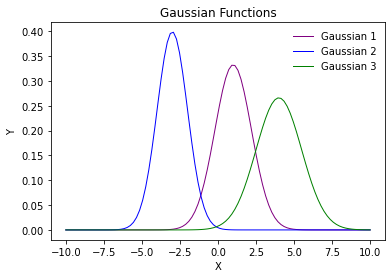

In [41]:
def gauss1D(x,mu,sigma):
    peak=1.0/(np.sqrt(2.0*np.pi)*sigma)
    return peak*np.exp(-(x-mu)**2/(2.0*sigma**2))

xg = np.linspace(-10,10,100)
yg1 = gauss1D(xg,1.0,1.2)
yg2 = gauss1D(xg,-3.0,1.0)
yg3 = gauss1D(xg,4.0,1.5)
plt.plot(xg,yg1, color= "purple", linewidth=1, linestyle="-", label="Gaussian 1")
plt.plot(xg,yg2, color= "blue", linewidth=1, linestyle="-", label="Gaussian 2")
plt.plot(xg,yg3, color= "green", linewidth=1, linestyle="-", label="Gaussian 3")
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Gaussian Functions')
plt.legend(loc= "upper right", frameon=False)
plt.show()

___________________________________________________________________________________________________________________________

## Problem 2: Rectangular Pulse

We can approximate the Heaviside step function by making a sigmoid as steep as posible. Start by creating the step function using the *sigmoid*:

\begin{align}
\textrm{sigmoid} = H(x-c)=\dfrac{1}{1+e^{-2(x-c)/a}} \qquad\text{(1)}
\textrm{}
\end{align}

Generate some $x$ points in the range of ($-xmax$,$xmax$), where $xmax$ can be 1 for starters, and then calculating $y$ using variations of the sigmoid function with $c$ and $a$ as parameters.
<hr>

Approximate a rectangular pulse by multiplying two sigmoids:
\begin{align}
\theta_1(x|a,c,d)  = H(x-c) * H(d-x) = \dfrac{1}{1+e^{-2(x-c)/a}} * \dfrac{1}{1+e^{-2(d-x)/a}}\qquad\text{(2)}
\textrm{}
\end{align}

<hr>



Part 1


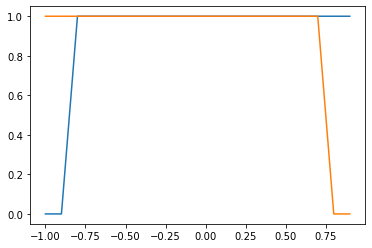

In [136]:
print('Part 1')
def sigmoid(a,c):
    y = 1/(1+np.exp(-2*(x-c)/a))
    plt.plot(x,y)
    
a=0.001
c=-0.85
x=np.arange(-1.0,1.0,.1)
sigmoid(a,c)

def sigmoid2(a2,d):
    y2 = 1/(1+np.exp(-2*(d-x)/a2))
    plt.plot(x,y2)
a2=0.002
d=0.75
sigmoid2(a2,d)


    

__________________________________________________________________________________________________________________________

Part 2


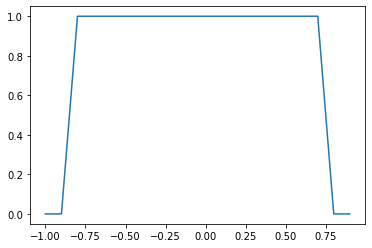

In [134]:
print("Part 2")
def pulse(a,c,a2,d):
    p=(1/(1+np.exp(-2*(x-c)/a)))*(1/(1+np.exp(-2*(d-x)/a2)))
    plt.plot(x,p)
pulse(a,c,a2,d)


## Problem 3 : 

Named after Jules Antoine Lissajous, a **Lissajous curve**, is the graph of a system of parametric equations which describe complex harmonic motion. The plots they create are really beautiful!

\begin{equation}
x(t)=Asin(at+c) \\
y(t)=Bsin(bt)
\end{equation}

For more see the entry in [Wikipedia](https://en.wikipedia.org/wiki/Lissajous_curve).

Choose the following values for the independent variable ($t$):

```
time = np.arange(0,100*np.pi,.1)
```

Make a function to draw this set of parametric equations for the following combinations of parameters:

1. $A=3, B=3, c=\frac{\pi}{10}, a=3, b=1$

2. $A=3, B=3, c=\frac{\pi}{10}, a=3, b=3$

3. $A=3, B=3, c=\frac{\pi}{10}, a=3, b=4$

4. A combination of your choosing (making art again!)

Comment on the effect that the ratio $\frac{a}{b}$ has on the shape produced.

1.


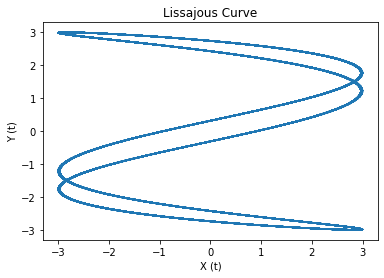

2.


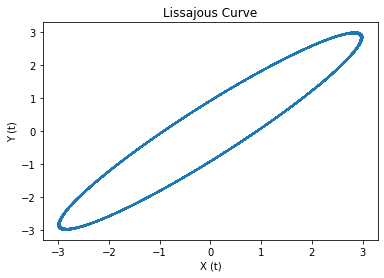

3.


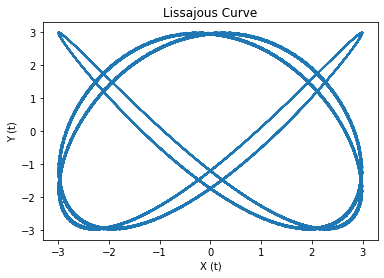

4.


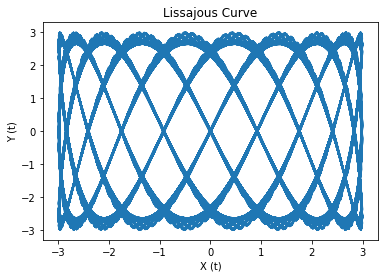

In general, a ratio of a/b produces a figure with a shape defined by 'a' horizontal lobes and 'b' vertical lobes.  An interesting case arises when a/b equals 1, which causes the shape to be an ellipse.  


In [82]:
print("1.")
def Lissajous(t,A,B,c,a,b):
    x=A*np.sin(a*t+c)
    y=B*np.sin(b*t) 
    plt.plot(x,y)
    plt.xlabel('X (t)')
    plt.ylabel('Y (t)')
    plt.title('Lissajous Curve')
    plt.show()
t=np.arange(0,100*np.pi,.1)
A=3
B=3
c=(np.pi)/10
a=3
b=1
Lissajous(t,A,B,c,a,b)
print('2.')
b=3
Lissajous(t,A,B,c,a,b)
print('3.')
b=4
Lissajous(t,A,B,c,a,b)
print('4.')
b=10
Lissajous(t,A,B,c,a,b)
print("In general, a ratio of a/b produces a figure with a shape defined by 'a' horizontal lobes and 'b' vertical lobes.  An interesting case arises when a/b equals 1, which causes the shape to be an ellipse.  ")

___________________________________________________________________________________________________________________________

## Problem 4 : 

In geometry, an **epicycloid** is a plane curve produced by tracing the path of a chosen point on the circumference of a circle—called an epicycle—which rolls without slipping around a fixed circle. It is a particular kind of roulette. *(source [Wikipedia](https://en.wikipedia.org/wiki/Epicycloid))*. When plotted the function should look something like this:

![epicycloid](epicycloid.png)

The function to create the epicycloid is:
\begin{equation}
x(t)=(a+b)\cos(t) - b\cos((a/b+1)t) \\
y(t)=(a+b)\sin(t) - b\sin((a/b+1)t)
\end{equation}

Where $a$, $b$ are integers.

Define a function that takes $t$, $a$, and $b$ as arguments, creates the epicycloid, and plots it.
```
def epic(t,a,b):
```
Call the function twice with two different sets of $a$ and $b$. Comment on how the function changes for various values of the variables $a$ and $b$.

If a > b, and a/b is an irreducible fraction, then the function will have "a" number of cusps. However, if a < b,  then the function will simply spiral. If a happens to equal b, you will see a cardioid!


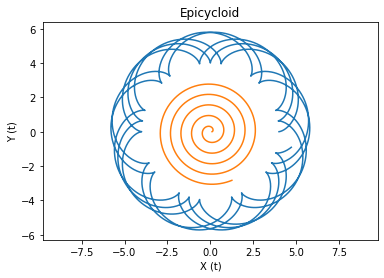

In [88]:
def epic(t,a,b):
    x = (a+b)*np.cos(t)-(b*np.cos((a/b+1)*t))
    y = (a+b)*np.sin(t)-(b*np.sin((a/b+1)*t))
    plt.plot(x,y)
    plt.title('Epicycloid')
    plt.xlabel('X (t)')
    plt.ylabel('Y (t)')
    plt.axis("equal")
a=4
b=0.9
t=np.arange(0,10*np.pi,0.01)
epic(t,a,b)

a=0.1
b=4
epic(t,a,b)

print('If a > b, and a/b is an irreducible fraction, then the function will have "a" number of cusps. However, if a < b,  then the function will simply spiral. If a happens to equal b, you will see a cardioid!')